In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

import mplhep as hep
hep.style.use("LHCb2")

In [2]:
names_dic = {
    'TaggingEfficiency': r'$\varepsilon_{\mathrm{tag}}$',
    'TaggingEfficiency_Cali': r'$\varepsilon^{\mathrm{cali}}_{\mathrm{tag}}$',
    'EffectiveMistag': r'$\omega$',
    'EffectiveMistag_Cali': r'$\omega^{\mathrm{cali}}$',
    'TaggingPower': r'$\varepsilon_{tag,\mathrm{eff}}$',
    'TaggingPower_Cali': r'$\varepsilon_{tag,\mathrm{eff}}^{\mathrm{cali}}$'
}

In [3]:
nom = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_IPSig/taggingInfo.json'
no_ghosts = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_noGhosts/taggingInfo.json'
eta_47 = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_eta4.7/taggingInfo.json'
eta_48 = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_eta4.8/taggingInfo.json'
low_pt = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_IPSig_lowPT/taggingInfo.json'

with open(nom) as f:
    _nom = json.load(f)
with open(eta_47) as f:
    _eta47 = json.load(f)
with open(eta_48) as f:
    _eta48 = json.load(f)
with open(no_ghosts) as f:
    _nogh = json.load(f)
with open(low_pt) as f:
    _lowpt = json.load(f)

In [4]:
for n in names_dic:
    if 'Cali' in n:
        print(n)
        print('Nom', np.round(_nom[n][0]*100,2), '+-', np.round(_nom[n][1]*100,2))
        # print('No ghosts', np.round(_nogh[n][0],4), '+-', np.round(_nogh[n][1],4))
        # print('eta>4.7', np.round(_eta47[n][0],4), '+-', np.round(_eta47[n][1],4))
        # print('eta>4.8', np.round(_eta47[n][0],4), '+-', np.round(_eta48[n][1],4), '\n')
        print('low PT K', np.round(_lowpt[n][0]*100,2), '+-', np.round(_lowpt[n][1]*100,2), '\n')


TaggingEfficiency_Cali
Nom 43.68 +- 0.07
low PT K 48.88 +- 0.07 

EffectiveMistag_Cali
Nom 40.95 +- 0.02
low PT K 41.27 +- 0.02 

TaggingPower_Cali
Nom 1.43 +- 0.01
low PT K 1.49 +- 0.01 



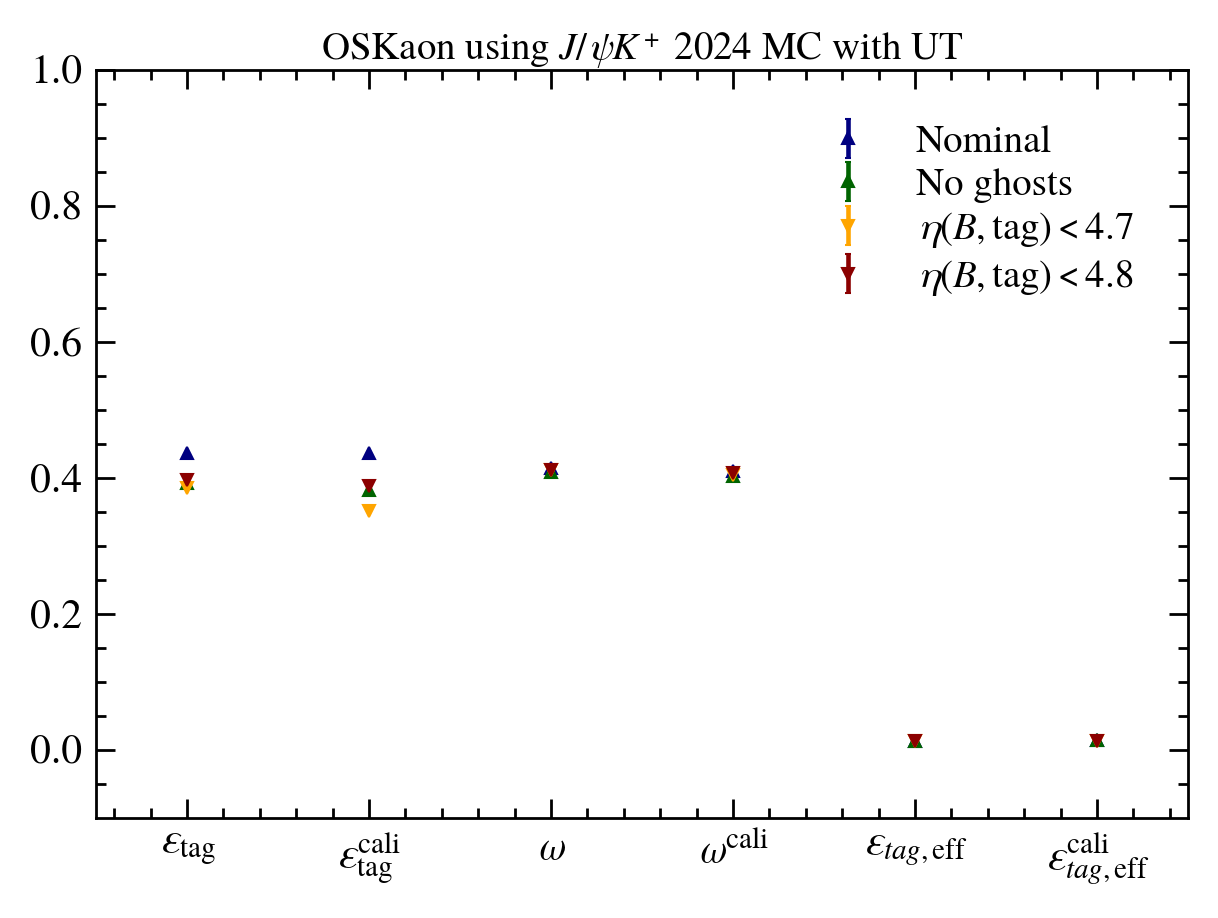

In [6]:
xvals = [n for n in names_dic.keys()]
x_names = [names_dic[n] for n in xvals]
yvals_nom = [_nom[k][0] for k in xvals]
yerr_nom = [_nom[k][1] for k in xvals]
yvals_eta47 = [_eta47[k][0] for k in xvals]
yerr_eta47 = [_eta47[k][1] for k in xvals]
yvals_eta48 = [_eta48[k][0] for k in xvals]
yerr_eta48 = [_eta48[k][1] for k in xvals]
yvals_nogh = [_nogh[k][0] for k in xvals]
yerr_err_nogh = [_nogh[k][1] for k in xvals]
plt.ylim(-0.1,1.0)
plt.xlim(0.,6.)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_nom, yerr=yerr_nom, label='Nominal', fmt='^', color="navy", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_nogh, yerr=yerr_err_nogh, label='No ghosts', fmt='^', color="darkgreen", markersize=8)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_trueid, yerr=yerr_trueid, label=r'$|\mathrm{TRUEID}(tag)!=0$', fmt='v', color="orange", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_eta47, yerr=yerr_eta47, label=r'$\eta(B, \mathrm{tag})<4.7$', fmt='v', color="orange", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_eta48, yerr=yerr_eta48, label=r'$\eta(B, \mathrm{tag})<4.8$', fmt='v', color="darkred", markersize=8)
plt.xticks(np.arange(len(xvals)) + 0.5, x_names)
plt.title('OSKaon using $J/\psi K^+$ 2024 MC with UT')
plt.legend(loc='best')
plt.show()
plt.close()